# Punching Shear — Example Notebook

This notebook demonstrates the `punching` module. It covers:

- Defining a `PunchingSlab` and declaring its top reinforcement
- Reading back the derived effective depths and reinforcement ratios
- Defining a `Column` (interior, edge, corner; rectangular or circular)
- Adding a `Capital` and an `Opening`
- Creating a `PunchingNode`, inspecting it with `.data` and drawing it with `.plot()`
- Which force components a punching node reads: `V_z` and the moments `M_x` / `M_y`

> **Status.** `check()` and `design()` are not implemented yet — ACI 318-19 arrives in
> Phase 2, the reinforcement design in Phase 4 and EN 1992 in Phase 5. The phase plan is
> `docs/architecture/punching-roadmap.md`. This notebook shows the geometry and
> reinforcement layer that feeds those calculations.

In [1]:
from mento import Concrete_ACI_318_19, Concrete_EN_1992_2004, SteelBar, Forces
from mento import MPa, mm, cm, kN, kNm
from mento import Column, PunchingSlab, Opening, Capital, PunchingNode

## 1. Materials and slab

A `PunchingSlab` holds the slab geometry, the materials and the top reinforcement over
the column.

- `h` — slab thickness
- `c_c` — clear cover to the outermost bar
- `outer_direction` — which top mat sits closest to the slab face (`"x"` by default)

The reinforcement is declared as **bars**, and the effective depths and reinforcement
ratios are derived from them. Position 1 is the base mat and position 3 the extra bars
over the column — *armadura base y refuerzo* — the same convention as
`OneWaySlab.set_slab_longitudinal_rebar_top`.

In [2]:
conc = Concrete_ACI_318_19(name="C25", f_c=25 * MPa)
steel = SteelBar(name="ADN 420", f_y=420 * MPa)

slab = PunchingSlab(
    concrete  = conc,
    steel_bar = steel,
    h   = 25 * cm,
    c_c = 25 * mm,
)

# Base mat Ø12/15 in both directions, plus Ø16/15 extra bars over the column in x.
slab.set_rebar_x(d_b1=12 * mm, s_b1=15 * cm, d_b3=16 * mm, s_b3=15 * cm)
slab.set_rebar_y(d_b1=12 * mm, s_b1=15 * cm)

slab.data

Punching slab, $h$=25.0 cm, $c_{c}$=2.5 cm, Concrete C25, Rebar ADN 420.

Top rebar x: Ø12/15.0 cm ++ Ø16/15.0 cm, $d_{x}$=21.7 cm, $\rho_{x}$=0.0097

Top rebar y: Ø12/15.0 cm, $d_{y}$=20.3 cm, $\rho_{y}$=0.0037

$d_{avg}$=21.0 cm, $\rho_{l}$=0.0060 (x outside y).

$A_{s,x}$=20.94 cm²/m, $A_{s,y}$=7.54 cm²/m.

### What gets derived from those bars

`d` and ρ are not independent — ρ = A_s /(b·d) — so neither is an input on its own.
Both come out of the declaration above:

```
d_x   = h - c_c - Ø_x/2              # x is the outer mat
d_y   = h - c_c - Ø_x - Ø_y/2        # y sits one bar lower
d_avg = (d_x + d_y)/2                # EN 1992-1-1 eq. (6.32); also ACI's d
ρ_x   = A_s,x / d_x   (per unit width)
ρ_l   = √(ρ_x · ρ_y)                 # EN 1992-1-1 §6.4.4(1)
```

The **largest** declared bar in a direction governs that mat's depth: two interleaved
sets of different diameters do not sit at one depth, and the larger one is what a
drawing dimensions to.

In [3]:
print(f"d_x   = {slab.d_x.to('cm'):.2f}")
print(f"d_y   = {slab.d_y.to('cm'):.2f}")
print(f"d_avg = {slab.d_avg.to('cm'):.2f}")
print()
print(f"A_s,x = {slab.A_s_x.to('cm**2/m'):.2f}")
print(f"A_s,y = {slab.A_s_y.to('cm**2/m'):.2f}")
print()
print(f"rho_x = {slab.rho_x:.5f}")
print(f"rho_y = {slab.rho_y:.5f}")
print(f"rho_l = {slab.rho_l:.5f}")

d_x   = 21.70 centimeter
d_y   = 20.30 centimeter
d_avg = 21.00 centimeter

A_s,x = 20.94 centimeter ** 2 / meter
A_s,y = 7.54 centimeter ** 2 / meter

rho_x = 0.00965
rho_y = 0.00371
rho_l = 0.00599


### The extra bars over the column are the point

ρ over the critical perimeter is what EN 1992 §6.4.4 reads for `v_Rd,c`, and the base mat
alone underestimates it. Declaring the refuerzo separately is what lets the check see it.

(ACI 318-19 is different: its `v_c` in §22.6.5 does not use ρ at all. ρ only reaches an
ACI check through the flexural moment transfer of §8.4.2.3, which is a later phase.)

In [4]:
base_only = PunchingSlab(concrete=conc, steel_bar=steel, h=25 * cm, c_c=25 * mm)
base_only.set_rebar_x(d_b1=12 * mm, s_b1=15 * cm)
base_only.set_rebar_y(d_b1=12 * mm, s_b1=15 * cm)

print(f"base mat only        rho_x = {base_only.rho_x:.5f}   rho_l = {base_only.rho_l:.5f}")
print(f"base mat + refuerzo  rho_x = {slab.rho_x:.5f}   rho_l = {slab.rho_l:.5f}")

base mat only        rho_x = 0.00344   rho_l = 0.00354
base mat + refuerzo  rho_x = 0.00965   rho_l = 0.00599


## 2. Declaring nothing

With no `set_rebar_*` call the effective depths fall back to a two-mat Ø16 (metric) /
#5 (imperial) estimate, which is the historical `d_avg = h - c_c - 16 mm`. That is enough
for an ACI punching check, whose `v_c` needs no ρ.

ρ is then `None` rather than zero — ρ = 0 would silently collapse `v_Rd,c` to `v_min` and
under-report the capacity, so an EN check refuses to run instead. `has_rebar` is the flag
that says which situation you are in.

In [5]:
bare = PunchingSlab(concrete=conc, steel_bar=steel, h=25 * cm, c_c=25 * mm)

print(f"d_avg      = {bare.d_avg.to('cm'):.2f}   (= h - c_c - 16 mm)")
print(f"d_x, d_y   = {bare.d_x.to('cm'):.2f}, {bare.d_y.to('cm'):.2f}")
print(f"rho_x      = {bare.rho_x}")
print(f"has_rebar  = {bare.has_rebar}")

d_avg      = 20.90 centimeter   (= h - c_c - 16 mm)
d_x, d_y   = 21.70 centimeter, 20.10 centimeter
rho_x      = None
has_rebar  = False


## 3. When you know the depth but not the bars

`d_avg` is derived and cannot be assigned: setting it would leave ρ computed against a
different depth, with nothing to detect it. Use `set_effective_depth()` instead — it sets
the depths *and* re-derives ρ against them, so the two stay consistent.

In [6]:
custom = PunchingSlab(concrete=conc, steel_bar=steel, h=25 * cm, c_c=25 * mm)
custom.set_rebar_x(d_b1=16 * mm, s_b1=15 * cm)
custom.set_rebar_y(d_b1=12 * mm, s_b1=15 * cm)

try:
    custom.d_avg = 20 * cm
except AttributeError as e:
    print(e)

d_avg is derived from d_x and d_y and cannot be assigned: it would leave rho_x and rho_y computed against a different depth. Declare the bars with set_rebar_x() / set_rebar_y(), or set the depths directly with set_effective_depth(d_x=..., d_y=...), which re-derives rho with them.


In [7]:
print(f"derived   d_avg = {custom.d_avg.to('cm'):.2f}   rho_x = {custom.rho_x:.5f}")

# A depth read off a drawing, for a layout the bar declaration cannot express.
custom.set_effective_depth(d_x=20.7 * cm, d_y=19.3 * cm)

print(f"overridden d_avg = {custom.d_avg.to('cm'):.2f}   rho_x = {custom.rho_x:.5f}   <- re-derived")

derived   d_avg = 21.00 centimeter   rho_x = 0.00618
overridden d_avg = 20.00 centimeter   rho_x = 0.00648   <- re-derived


### `outer_direction`

Which mat sits closest to the top face moves each effective depth by one bar diameter.
It is a real detailing choice, so it is an input rather than a convention.

In [8]:
for direction in ("x", "y"):
    s = PunchingSlab(concrete=conc, steel_bar=steel, h=25 * cm, c_c=25 * mm, outer_direction=direction)
    s.set_rebar_x(d_b1=16 * mm, s_b1=15 * cm)
    s.set_rebar_y(d_b1=12 * mm, s_b1=15 * cm)
    print(f"{direction} outside:  d_x = {s.d_x.to('cm'):.2f}   d_y = {s.d_y.to('cm'):.2f}   d_avg = {s.d_avg.to('cm'):.2f}")

x outside:  d_x = 21.70 centimeter   d_y = 20.30 centimeter   d_avg = 21.00 centimeter
y outside:  d_x = 20.50 centimeter   d_y = 21.90 centimeter   d_avg = 21.20 centimeter


## 4. Which force components a punching node reads

A punching node is not a member but a **column-to-slab connection**, so it reads a
different subset of `Forces` than a beam does:

| Component | At a punching node |
| --- | --- |
| `V_z` | **The design punching load** — the vertical force transferred at the connection. This is what both codes call the demand: `V_u` in ACI 318-19 §22.6, `V_Ed` in EN 1992-1-1 §6.4. |
| `M_x`, `M_y` | **The unbalanced moments** transferred to the slab, about its two in-plane axes. |
| `N_x` | **Not used.** |

Taking the column's axial load as `V_z` is a simplification, and a common one — both codes
let the load acting *inside* the control perimeter be deducted (EN writes it `V_Ed,red`,
§6.4.3(3)), and at an edge or corner column the two are not the same number anyway. mento
takes `V_z` as the design punching load you have already worked out.

Note that `M_x` means something different here than on a beam, where a moment about the
longitudinal axis is torsion. At a punching node there is no longitudinal axis, and `M_x`
is an in-plane moment on the slab. The full convention is in
`docs/source/user_guide/local_axes.rst`.

## 5. Case 1 — interior rectangular column

The simplest case: a square column surrounded by slab on all sides, concentric vertical
load only.

`Column` parameters:
- `shape`: `"rectangular"` or `"circular"`
- `position`: `"interior"`, `"edge"` or `"corner"`
- `b`, `h`: column dimensions in x and y

`node.data` is the view to reach for at the REPL — a slab on its own does not know its
column, and checking the geometry you just typed means seeing both.

In [9]:
col_interior = Column(
    shape    = "rectangular",
    position = "interior",
    b = 40 * cm,
    h = 40 * cm,
)

f1 = Forces(label="ELU 1", V_z=500 * kN)

node_1 = PunchingNode(
    slab   = slab,
    column = col_interior,
    forces = f1,
)

node_1.data

**Punching node 1** — interior rectangular column, $b$=40.0 cm, $h$=40.0 cm.

Punching slab, $h$=25.0 cm, $c_{c}$=2.5 cm, Concrete C25, Rebar ADN 420.

Top rebar x: Ø12/15.0 cm ++ Ø16/15.0 cm, $d_{x}$=21.7 cm, $\rho_{x}$=0.0097

Top rebar y: Ø12/15.0 cm, $d_{y}$=20.3 cm, $\rho_{y}$=0.0037

$d_{avg}$=21.0 cm, $\rho_{l}$=0.0060 (x outside y).

$A_{s,x}$=20.94 cm²/m, $A_{s,y}$=7.54 cm²/m.

Forces:

- ELU 1: $V$=500.0 kN

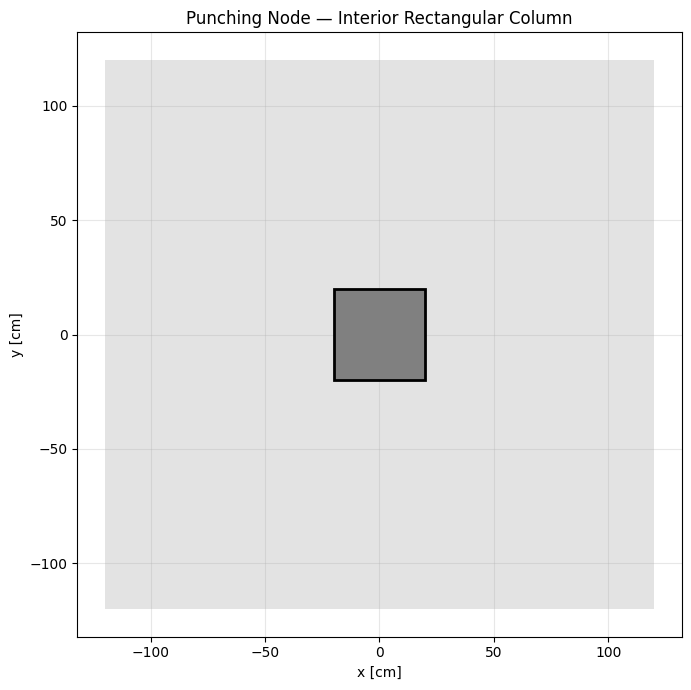

In [10]:
node_1.plot()

## 6. Case 2 — edge column with a uniaxial moment

An edge column has one free slab edge. Supply `edge_distance_x` — the distance from the
column centroid to the free edge in x. The hatched region in the plot is outside the slab.

Forces are the punching load `V_z` plus `M_y`, the unbalanced moment about the y-axis
(typical for a frame spanning in x).

**Punching node 2** — edge rectangular column, $b$=40.0 cm, $h$=40.0 cm. Distance to free edge: $x$=20.0 cm.

Punching slab, $h$=25.0 cm, $c_{c}$=2.5 cm, Concrete C25, Rebar ADN 420.

Top rebar x: Ø12/15.0 cm ++ Ø16/15.0 cm, $d_{x}$=21.7 cm, $\rho_{x}$=0.0097

Top rebar y: Ø12/15.0 cm, $d_{y}$=20.3 cm, $\rho_{y}$=0.0037

$d_{avg}$=21.0 cm, $\rho_{l}$=0.0060 (x outside y).

$A_{s,x}$=20.94 cm²/m, $A_{s,y}$=7.54 cm²/m.

Forces:

- ELU 1: $V$=300.0 kN, $M_{y}$=50.0 kN·m

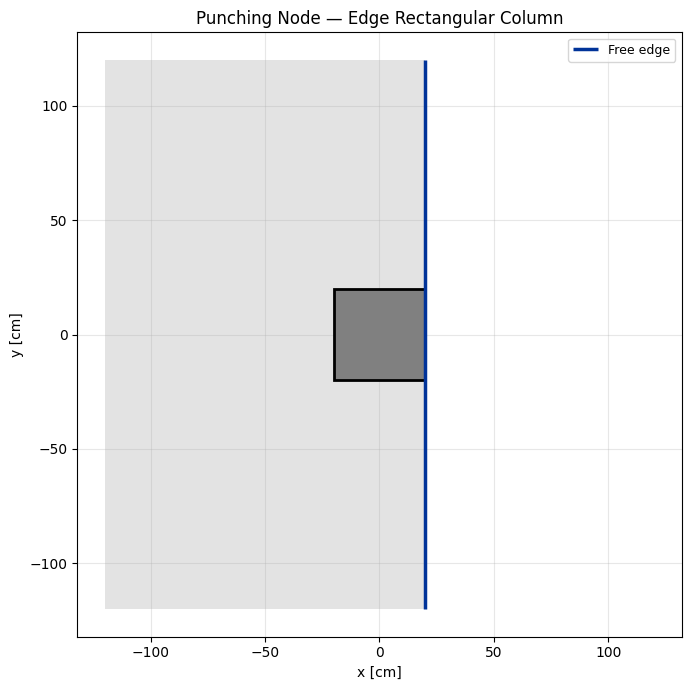

In [11]:
col_edge = Column(
    shape    = "rectangular",
    position = "edge",
    b = 40 * cm,
    h = 40 * cm,
    edge_distance_x = 20 * cm,   # column face flush with the slab edge
)

f2 = Forces(label="ELU 1", V_z=300 * kN, M_y=50 * kNm)

node_2 = PunchingNode(
    slab   = slab,
    column = col_edge,
    forces = f2,
)

node_2.data
node_2.plot()

## 7. Case 3 — corner column with capital, opening and biaxial moment

A corner column has two free edges, so both `edge_distance_x` and `edge_distance_y` are
required.

A **`Capital`** (column head / drop panel) is defined by its plan dimensions and its
thickness below the slab soffit. It creates two critical perimeters to check — at d/2 from
the capital edge and at d/2 from the column face with the reduced d (Phase 3).

An **`Opening`** is positioned by its centroid offset from the column centroid (`x`, `y`).
Openings close to the column cut into the critical perimeter (Phase 3).

Forces now carry **`M_x`** as well, for biaxial transfer.

**Punching node 3** — corner rectangular column, $b$=40.0 cm, $h$=40.0 cm. Distance to free edge: $x$=50.0 cm, $y$=50.0 cm. Capital 80.0 cm × 80.0 cm, thickness 25.0 cm. 1 opening(s).

Punching slab, $h$=25.0 cm, $c_{c}$=2.5 cm, Concrete C25, Rebar ADN 420.

Top rebar x: Ø12/15.0 cm ++ Ø16/15.0 cm, $d_{x}$=21.7 cm, $\rho_{x}$=0.0097

Top rebar y: Ø12/15.0 cm, $d_{y}$=20.3 cm, $\rho_{y}$=0.0037

$d_{avg}$=21.0 cm, $\rho_{l}$=0.0060 (x outside y).

$A_{s,x}$=20.94 cm²/m, $A_{s,y}$=7.54 cm²/m.

Forces:

- ELU 1: $V$=200.0 kN, $M_{x}$=20.0 kN·m, $M_{y}$=30.0 kN·m

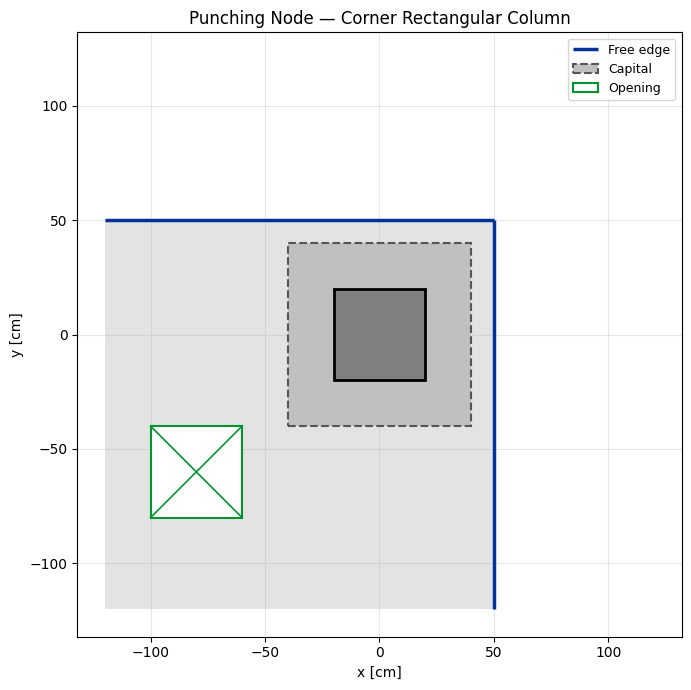

In [12]:
col_corner = Column(
    shape    = "rectangular",
    position = "corner",
    b = 40 * cm,
    h = 40 * cm,
    edge_distance_x = 50 * cm,
    edge_distance_y = 50 * cm,
)

capital = Capital(
    b         = 80 * cm,
    h         = 80 * cm,
    thickness = 25 * cm,
)

opening = Opening(
    shape = "rectangular",
    x = -80 * cm,   # 80 cm to the left of the column centroid
    y = -60 * cm,   # 60 cm below it
    b = 40 * cm,
    h = 40 * cm,
)

# Biaxial transfer: M_y (about the y-axis) + M_x (about the x-axis)
f3 = Forces(label="ELU 1", V_z=200 * kN, M_y=30 * kNm, M_x=20 * kNm)

node_3 = PunchingNode(
    slab     = slab,
    column   = col_corner,
    forces   = f3,
    openings = [opening],
    capital  = capital,
)

node_3.data
node_3.plot()

## 8. Case 4 — interior circular column

For a circular column pass the diameter as `b`; `h` is not used.

**Punching node 4** — interior circular column, $D$=50.0 cm.

Punching slab, $h$=25.0 cm, $c_{c}$=2.5 cm, Concrete C25, Rebar ADN 420.

Top rebar x: Ø12/15.0 cm ++ Ø16/15.0 cm, $d_{x}$=21.7 cm, $\rho_{x}$=0.0097

Top rebar y: Ø12/15.0 cm, $d_{y}$=20.3 cm, $\rho_{y}$=0.0037

$d_{avg}$=21.0 cm, $\rho_{l}$=0.0060 (x outside y).

$A_{s,x}$=20.94 cm²/m, $A_{s,y}$=7.54 cm²/m.

Forces:

- ELU 1: $V$=500.0 kN

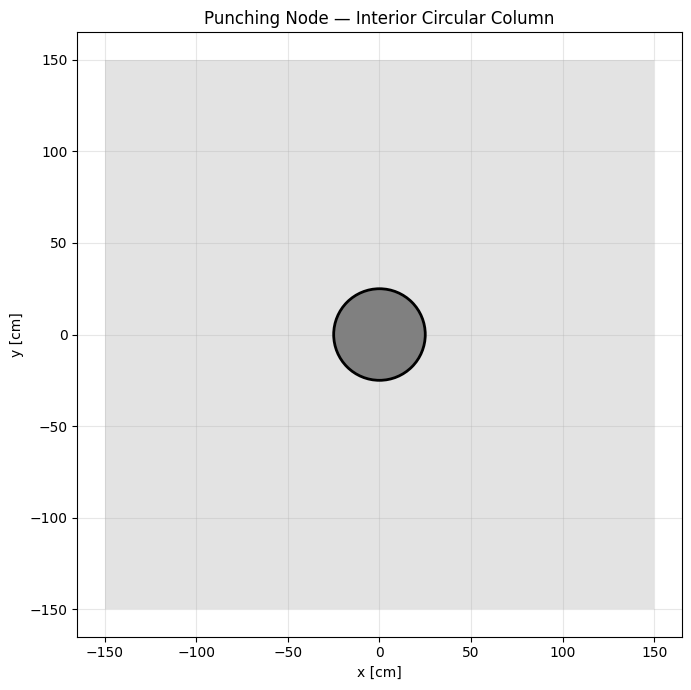

In [13]:
col_circular = Column(
    shape    = "circular",
    position = "interior",
    b = 50 * cm,   # diameter
)

node_4 = PunchingNode(
    slab   = slab,
    column = col_circular,
    forces = f1,
)

node_4.data
node_4.plot()

## 9. Several load combinations on one node

Pass a list of `Forces` to carry every combination on the node. Once `check()` lands
(Phase 2) it will iterate over them and report the governing DCR.

In [14]:
fa = Forces(label="1.4D",      V_z=480 * kN, M_y= 40 * kNm)
fb = Forces(label="1.2D+1.6L", V_z=550 * kN, M_y= 60 * kNm)
fc = Forces(label="1.2D+1.0W", V_z=410 * kN, M_y=110 * kNm)

node_multi = PunchingNode(
    slab   = slab,
    column = col_interior,
    forces = [fa, fb, fc],
)

node_multi.data

**Punching node 5** — interior rectangular column, $b$=40.0 cm, $h$=40.0 cm.

Punching slab, $h$=25.0 cm, $c_{c}$=2.5 cm, Concrete C25, Rebar ADN 420.

Top rebar x: Ø12/15.0 cm ++ Ø16/15.0 cm, $d_{x}$=21.7 cm, $\rho_{x}$=0.0097

Top rebar y: Ø12/15.0 cm, $d_{y}$=20.3 cm, $\rho_{y}$=0.0037

$d_{avg}$=21.0 cm, $\rho_{l}$=0.0060 (x outside y).

$A_{s,x}$=20.94 cm²/m, $A_{s,y}$=7.54 cm²/m.

Forces:

- 1.4D: $V$=480.0 kN, $M_{y}$=40.0 kN·m
- 1.2D+1.6L: $V$=550.0 kN, $M_{y}$=60.0 kN·m
- 1.2D+1.0W: $V$=410.0 kN, $M_{y}$=110.0 kN·m

## 10. Imperial units

The unit system follows the concrete: `f_c` in psi gives an imperial slab, and the
fallback bar estimate becomes a #5 instead of a Ø16.

In [15]:
from mento import psi, inch

conc_imp = Concrete_ACI_318_19(name="C4", f_c=4000 * psi)
slab_imp = PunchingSlab(concrete=conc_imp, steel_bar=steel, h=10 * inch, c_c=1 * inch)
slab_imp.set_rebar_x(d_b1=0.625 * inch, s_b1=12 * inch)
slab_imp.set_rebar_y(d_b1=0.500 * inch, s_b1=12 * inch)

slab_imp.data

Punching slab, $h$=10.00 in, $c_{c}$=1.00 in, Concrete C4, Rebar ADN 420.

Top rebar x: Ø0.625/12.00 in, $d_{x}$=8.69 in, $\rho_{x}$=0.0029

Top rebar y: Ø0.500/12.00 in, $d_{y}$=8.12 in, $\rho_{y}$=0.0020

$d_{avg}$=8.41 in, $\rho_{l}$=0.0024 (x outside y).

$A_{s,x}$=0.31 in²/ft, $A_{s,y}$=0.20 in²/ft.

## 11. What is wired, and what is missing

`check()` is wired end to end: it dispatches through the design-code registry, so the
connection never names a code, and it returns a frozen `PunchingCheck` — not a DataFrame
— with the report tables built in `mento/reports/punching.py` (ADR-0001, ADR-0004).

What is missing is the arithmetic. The equations of
`mento/codes/aci_318_19/equations/punching.py` and its EN counterpart are signatures with
their clause and their argument units, and bodies that raise, because the formulas are
being recreated from a validated Calcpad sheet.

In [16]:
try:
    node_1.check()
except NotImplementedError as e:
    print(f"ACI check:  {e}")
    print()

try:
    node_1.design()
except NotImplementedError as e:
    print(f"design():   {e}")

ACI check:  The ACI 318-19 punching check is not implemented yet: Phase 2 of docs/architecture/punching-roadmap.md. The geometry, the reinforcement and the result type are in place; the equations of mento.codes.aci_318_19.equations.punching are not.

design():   design punching is not implemented for design code: ACI 318-19


### The preconditions are real

What the check *does* enforce today is what Phase 2 will rely on, so a mistake in the
input is caught by name rather than becoming a plausible-looking number later.

In [17]:
cases = {
    "no punching load": PunchingNode(
        slab=slab, column=col_interior, forces=Forces(label="ELU", M_y=50 * kNm)
    ),
    "capital (Phase 3)": PunchingNode(
        slab=slab, column=col_interior, forces=f1, capital=capital
    ),
    "opening (Phase 3)": PunchingNode(
        slab=slab, column=col_interior, forces=f1, openings=[opening]
    ),
    # EN reads rho for v_Rd,c; ACI never does, so only EN refuses this one.
    "EN, no rho declared": PunchingNode(
        slab=PunchingSlab(
            concrete=Concrete_EN_1992_2004(name="C25/30", f_c=25 * MPa),
            steel_bar=steel, h=25 * cm, c_c=25 * mm,
        ),
        column=col_interior, forces=f1,
    ),
}

for name, node in cases.items():
    try:
        node.check()
    except (ValueError, NotImplementedError) as e:
        print(f"{name}:")
        print(f"  {e}")
        print()

no punching load:
  Forces 'ELU' carries no vertical load, so there is nothing to punch the slab. The punching load is V_z — Vu under ACI 318-19, VEd under EN 1992-1-1 — see docs/source/user_guide/local_axes.rst.

capital (Phase 3):
  A capital changes which critical perimeters have to be checked; that arrives in Phase 3 of docs/architecture/punching-roadmap.md.

opening (Phase 3):
  An opening near the column removes part of the critical perimeter; that arrives in Phase 3 of docs/architecture/punching-roadmap.md.

EN, no rho declared:
  EN 1992-1-1 §6.4.4 computes v_Rd,c from the flexural reinforcement ratio, and this slab has none declared in both directions. Declare it with set_rebar_x() and set_rebar_y().

